# Tarea final: Árboles de Decisión para regresión

**Objetivo:** desarrollar la tarea final de la clase usando un árbol de decisión de regresión para predecir precios de inmuebles de Ames, Iowa.

La variable objetivo es `Sale_Price`. El desarrollo sigue la lógica vista en la clase:

1. Preparación del ambiente.
2. Recodificación $k-1$ de variables categóricas con `pd.get_dummies(drop_first=True)`.
3. División entrenamiento/validación.
4. Entrenamiento de `DecisionTreeRegressor` sin modificar hiperparámetros.
5. Evaluación con métricas de regresión.
6. Importancia relativa de atributos.
7. Selección de los 10 atributos más importantes.
8. Refactorización con `GridSearchCV`.
9. Serialización del modelo y conjuntos de entrenamiento/validación con `pickle`.

Este notebook está preparado para trabajar con el archivo original `ames_housing.csv` entregado para la tarea.

## Ejercicio 1: Preparación del ambiente de trabajo

Se importan las librerías clásicas, `DecisionTreeRegressor`, las funciones de métricas para regresión, `train_test_split`, `GridSearchCV` y `pickle` para serializar el modelo final.

Además, al cargar la base se elimina la columna `Unnamed: 0`, tal como pide la tarea.

In [1]:
# Librerías clásicas
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modelo, partición, validación cruzada y métricas
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    r2_score
)

# Configuración general
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 11238

In [2]:
def clean_column_name(col):
    '''Estandariza nombres de columnas para evitar problemas por espacios o símbolos.'''
    col = col.strip().replace(' ', '_').replace('/', '_').replace('-', '_')
    col = re.sub(r'[^0-9A-Za-z_]+', '', col)
    col = re.sub(r'_+', '_', col)
    return col

# Carga de datos.
# El primer archivo corresponde al CSV original enviado para esta tarea.
possible_files = ['ames_housing.csv', 'AmesHousing.csv', 'AmesHousing.txt']
for file in possible_files:
    if os.path.exists(file):
        if file.endswith('.txt'):
            df = pd.read_csv(file, sep='\t')
        else:
            df = pd.read_csv(file)
        print(f'Archivo cargado: {file}')
        break
else:
    raise FileNotFoundError('No se encontró ames_housing.csv, AmesHousing.csv ni AmesHousing.txt en la carpeta del notebook.')

# Limpieza de nombres y compatibilidad con la variable objetivo de la tarea.
df.columns = [clean_column_name(col) for col in df.columns]
if 'SalePrice' in df.columns and 'Sale_Price' not in df.columns:
    df = df.rename(columns={'SalePrice': 'Sale_Price'})

# Eliminar Unnamed: 0 si existe.
# Después de clean_column_name, esta columna queda como Unnamed_0.
unnamed_cols = [col for col in df.columns if col.startswith('Unnamed')]
df = df.drop(columns=unnamed_cols)

print(f'Dimensiones de la base: {df.shape[0]} filas y {df.shape[1]} columnas')
print(f'Columnas eliminadas por ser Unnamed: {unnamed_cols}')
print(f'Variable objetivo Sale_Price disponible: {"Sale_Price" in df.columns}')
df.head()

Archivo cargado: ames_housing.csv
Dimensiones de la base: 2930 filas y 81 columnas
Columnas eliminadas por ser Unnamed: ['Unnamed_0']
Variable objetivo Sale_Price disponible: True


,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,First_Flr_SF,Second_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Average,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,Typical,Typical,CBlock,Typical,Good,Gd,BLQ,2,Unf,0,441,1080,GasA,Fair,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,Typical,7,Typ,2,Good,Attchd,Fin,2,528,Typical,Typical,Partial_Pavement,210,62,0,0,0,0,No_Pool,No_Fence,NaN,0,5,2010,WD,Normal,215000,-93.6198,42.0540
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,Feedr,Norm,OneFam,One_Story,Average,Above_Average,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0,Typical,Typical,CBlock,Typical,Typical,No,Rec,6,LwQ,144,270,882,GasA,Typical,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,Typical,5,Typ,0,No_Fireplace,Attchd,Unf,1,730,Typical,Typical,Paved,140,0,0,0,120,0,No_Pool,Minimum_Privacy,NaN,0,6,2010,WD,Normal,105000,-93.6198,42.0530
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Above_Average,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,Typical,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,406,1329,GasA,Typical,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Good,6,Typ,0,No_Fireplace,Attchd,Unf,1,312,Typical,Typical,Paved,393,36,0,0,0,0,No_Pool,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.6194,42.0527
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Good,Average,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0,Good,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,1045,2110,GasA,Excellent,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Excellent,8,Typ,2,Typical,Attchd,Fin,2,522,Typical,Typical,Paved,0,0,0,0,0,0,No_Pool,No_Fence,NaN,0,4,2010,WD,Normal,244000,-93.6173,42.0512
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,OneFam,Two_Story,Average,Average,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0,Typical,Typical,PConc,Good,Typical,No,GLQ,3,Unf,0,137,928,GasA,Good,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,Typical,6,Typ,1,Typical,Attchd,Fin,2,482,Typical,Typical,Paved,212,34,0,0,0,0,No_Pool,Minimum_Privacy,NaN,0,3,2010,WD,Normal,189900,-93.6389,42.0609


In [3]:
# Medidas descriptivas generales
print('Resumen de Sale_Price:')
display(df['Sale_Price'].describe())

# Tipos de datos y valores perdidos
resumen_tipos = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values(['missing', 'dtype'], ascending=[False, True])

resumen_tipos.head(15)

Resumen de Sale_Price:


count     2,930.0000
mean    180,796.0601
std      79,886.6924
min      12,789.0000
25%     129,500.0000
50%     160,000.0000
75%     213,500.0000
max     755,000.0000
Name: Sale_Price, dtype: float64

,dtype,missing,missing_pct
Misc_Feature,object,2824,96.3800
Mas_Vnr_Type,object,1775,60.5800
Longitude,float64,0,0.0000
Latitude,float64,0,0.0000
Lot_Frontage,int64,0,0.0000
Lot_Area,int64,0,0.0000
Year_Built,int64,0,0.0000
Year_Remod_Add,int64,0,0.0000
Mas_Vnr_Area,int64,0,0.0000
BsmtFin_SF_1,int64,0,0.0000


## Ejercicio 2: Feature engineering

La tarea pide identificar las columnas de tipo `object` y, para cada una, generar una recodificación $k-1$ mediante variables binarias.

Procedimiento aplicado:

- Se identifican variables `object` y no `object`.
- Se reemplazan valores perdidos categóricos por `Missing`, para que `pd.get_dummies` los trate como categoría informativa.
- Se reemplazan valores perdidos numéricos por la mediana de cada columna. En esta versión del archivo original no aparecen valores perdidos numéricos, pero el paso queda incluido para mantener robustez.
- Se generan dummies con `drop_first=True`.
- Se concatenan las dummies con `pd.concat`.
- Se eliminan las variables categóricas originales para evitar duplicidad de información.

In [4]:
# Identificación de variables categóricas y no categóricas
object_cols = df.select_dtypes(include='object').columns.tolist()
non_object_cols = df.select_dtypes(exclude='object').columns.tolist()

print(f'Variables object: {len(object_cols)}')
print(f'Variables no object: {len(non_object_cols)}')
print('\nPrimeras variables object:')
print(object_cols[:15])

Variables object: 46
Variables no object: 35

Primeras variables object:
['MS_SubClass', 'MS_Zoning', 'Street', 'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Type', 'House_Style', 'Overall_Qual']


In [5]:
# Copia de trabajo para modelamiento
df_model = df.copy()

# Eliminar identificadores si existieran; no representan características reales del inmueble.
identifier_cols = [col for col in ['Order', 'PID', 'Id'] if col in df_model.columns]
df_model = df_model.drop(columns=identifier_cols)
print('Columnas identificadoras eliminadas:', identifier_cols)

# Recalcular columnas luego de eliminar identificadores
object_cols = df_model.select_dtypes(include='object').columns.tolist()
numeric_cols = df_model.select_dtypes(exclude='object').columns.tolist()

# Imputación simple
for col in object_cols:
    df_model[col] = df_model[col].fillna('Missing')

for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Recodificación k - 1 y concatenación con pd.concat
for col in object_cols:
    dummies = pd.get_dummies(df_model[col], drop_first=True, prefix=col, dtype=int)
    df_model = pd.concat([df_model, dummies], axis=1)

# Eliminar variables categóricas originales
encoded_df = df_model.drop(columns=object_cols)

print(f'Dimensiones antes de dummies: {df.shape}')
print(f'Dimensiones después de feature engineering: {encoded_df.shape}')
print(f'Valores perdidos restantes: {encoded_df.isna().sum().sum()}')
encoded_df.head()

Columnas identificadoras eliminadas: []
Dimensiones antes de dummies: (2930, 81)
Dimensiones después de feature engineering: (2930, 307)
Valores perdidos restantes: 0


,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Cars,Garage_Area,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude,MS_SubClass_One_Story_1945_and_Older,MS_SubClass_One_Story_1946_and_Newer_All_Styles,MS_SubClass_One_Story_PUD_1946_and_Newer,MS_SubClass_One_Story_with_Finished_Attic_All_Ages,MS_SubClass_One_and_Half_Story_Finished_All_Ages,MS_SubClass_One_and_Half_Story_PUD_All_Ages,MS_SubClass_One_and_Half_Story_Unfinished_All_Ages,MS_SubClass_PUD_Multilevel_Split_Level_Foyer,MS_SubClass_Split_Foyer,MS_SubClass_Split_or_Multilevel,MS_SubClass_Two_Family_conversion_All_Styles_and_Ages,MS_SubClass_Two_Story_1945_and_Older,MS_SubClass_Two_Story_1946_and_Newer,MS_SubClass_Two_Story_PUD_1946_and_Newer,MS_SubClass_Two_and_Half_Story_All_Ages,MS_Zoning_C_all,MS_Zoning_Floating_Village_Residential,MS_Zoning_I_all,MS_Zoning_Residential_High_Density,MS_Zoning_Residential_Low_Density,MS_Zoning_Residential_Medium_Density,Street_Pave,Alley_No_Alley_Access,Alley_Paved,Lot_Shape_Moderately_Irregular,...,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sal,Functional_Sev,Functional_Typ,Fireplace_Qu_Fair,Fireplace_Qu_Good,Fireplace_Qu_No_Fireplace,Fireplace_Qu_Poor,Fireplace_Qu_Typical,Garage_Type_Basment,Garage_Type_BuiltIn,Garage_Type_CarPort,Garage_Type_Detchd,Garage_Type_More_Than_Two_Types,Garage_Type_No_Garage,Garage_Finish_No_Garage,Garage_Finish_RFn,Garage_Finish_Unf,Garage_Qual_Fair,Garage_Qual_Good,Garage_Qual_No_Garage,Garage_Qual_Poor,Garage_Qual_Typical,Garage_Cond_Fair,Garage_Cond_Good,Garage_Cond_No_Garage,Garage_Cond_Poor,Garage_Cond_Typical,Paved_Drive_Partial_Pavement,Paved_Drive_Paved,Pool_QC_Fair,Pool_QC_Good,Pool_QC_No_Pool,Pool_QC_Typical,Fence_Good_Wood,Fence_Minimum_Privacy,Fence_Minimum_Wood_Wire,Fence_No_Fence,Misc_Feature_Gar2,Misc_Feature_Missing,Misc_Feature_Othr,Misc_Feature_Shed,Misc_Feature_TenC,Sale_Type_CWD,Sale_Type_Con,Sale_Type_ConLD,Sale_Type_ConLI,Sale_Type_ConLw,Sale_Type_New,Sale_Type_Oth,Sale_Type_VWD,Sale_Type_WD,Sale_Condition_AdjLand,Sale_Condition_Alloca,Sale_Condition_Family,Sale_Condition_Normal,Sale_Condition_Partial
0,141,31770,1960,1960,112,2,0,441,1080,1656,0,0,1656,1,0,1,0,3,1,7,2,2,528,210,62,0,0,0,0,0,5,2010,215000,-93.6198,42.0540,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,80,11622,1961,1961,0,6,144,270,882,896,0,0,896,0,0,1,0,2,1,5,0,1,730,140,0,0,0,120,0,0,6,2010,105000,-93.6198,42.0530,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,81,14267,1958,1958,108,1,0,406,1329,1329,0,0,1329,0,0,1,1,3,1,6,0,1,312,393,36,0,0,0,0,12500,6,2010,172000,-93.6194,42.0527,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
3,93,11160,1968,1968,0,1,0,1045,2110,2110,0,0,2110,1,0,2,1,3,1,8,2,2,522,0,0,0,0,0,0,0,4,2010,244000,-93.6173,42.0512,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,74,13830,1997,1998,0,3,0,137,928,928,701,0,1629,0,0,2,1,3,1,6,1,2,482,212,34,0,0,0,0,0,3,2010,189900,-93.6389,42.0609,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


## Ejercicio 3: Primer modelo

Se genera la matriz de atributos `X` y el vector objetivo `y = Sale_Price`. Luego se separa la muestra en entrenamiento y validación con:

- `test_size = 0.33`
- `random_state = 11238`

Después se entrena un `DecisionTreeRegressor` sin modificar sus hiperparámetros.

In [6]:
# Matriz de atributos y vector objetivo
if 'Sale_Price' not in encoded_df.columns:
    raise ValueError('No se encontró la variable objetivo Sale_Price.')

y = encoded_df['Sale_Price']
X = encoded_df.drop(columns='Sale_Price')

# División entrenamiento / validación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=RANDOM_STATE
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (1963, 306)
X_test: (967, 306)
y_train: (1963,)
y_test: (967,)


In [7]:
def report_scores(y_true, y_pred, model_name):
    '''Entrega métricas principales para modelos de regresión.'''
    mse = mean_squared_error(y_true, y_pred)
    return pd.DataFrame({
        'Modelo': [model_name],
        'MSE': [mse],
        'RMSE': [np.sqrt(mse)],
        'MAE': [mean_absolute_error(y_true, y_pred)],
        'MedAE': [median_absolute_error(y_true, y_pred)],
        'R2': [r2_score(y_true, y_pred)]
    })

# Modelo por defecto, sin modificar hiperparámetros
default_tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
default_tree.fit(X_train, y_train)

# Predicciones en entrenamiento y validación
y_hat_train_default = default_tree.predict(X_train)
y_hat_test_default = default_tree.predict(X_test)

# Métricas
default_scores = pd.concat([
    report_scores(y_train, y_hat_train_default, 'Train - árbol por defecto'),
    report_scores(y_test, y_hat_test_default, 'Validación - árbol por defecto')
], ignore_index=True)

default_scores

,Modelo,MSE,RMSE,MAE,MedAE,R2
0,Train - árbol por defecto,0.0000,0.0000,0.0000,0.0000,1.0000
1,Validación - árbol por defecto,"1,556,632,948.0972","39,454.1880","24,349.7787","16,400.0000",0.7261


**Comentario del primer modelo**

El árbol por defecto tiende a ajustar extremadamente bien la muestra de entrenamiento, porque no restringe la profundidad máxima ni el tamaño mínimo de los nodos terminales. Si el R2 de entrenamiento es muy alto y el de validación baja, hay evidencia de sobreajuste.

Para evaluar el desempeño real se debe priorizar la muestra de validación, especialmente `RMSE`, `MAE` y `R2`.

## Ejercicio 4: Importancia relativa

Se implementa `plot_importance`, método usado en la lectura para visualizar la importancia relativa de los atributos. La función extrae `feature_importances_` del árbol entrenado, ordena los predictores de mayor a menor importancia y genera un gráfico.

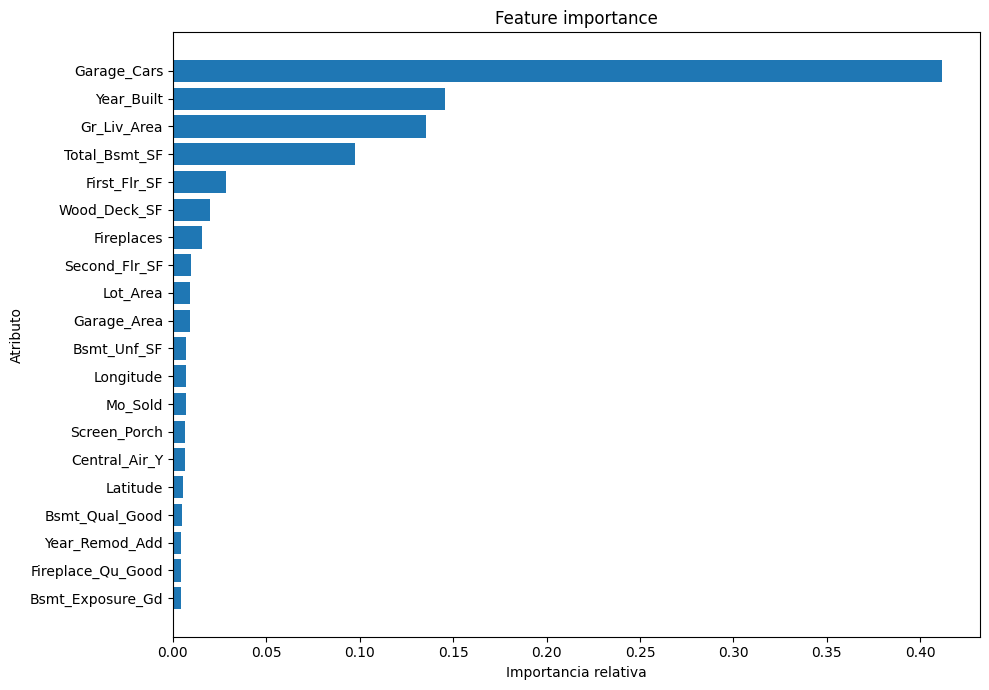

,atributo,importancia
0,Garage_Cars,0.4114
1,Year_Built,0.1457
2,Gr_Liv_Area,0.1356
3,Total_Bsmt_SF,0.0972
4,First_Flr_SF,0.0285
5,Wood_Deck_SF,0.0198
6,Fireplaces,0.0157
7,Second_Flr_SF,0.0099
8,Lot_Area,0.0093
9,Garage_Area,0.0089


In [8]:
def plot_importance(fit_model, feat_names, top_n=20):
    '''Grafica la importancia relativa de los atributos de un árbol entrenado.'''
    importance = fit_model.feature_importances_
    sorted_idx = np.argsort(importance)[::-1]

    importance_df = pd.DataFrame({
        'atributo': np.array(feat_names)[sorted_idx],
        'importancia': importance[sorted_idx]
    })

    plot_df = importance_df.head(top_n).iloc[::-1]
    plt.figure(figsize=(10, max(6, top_n * 0.35)))
    plt.barh(plot_df['atributo'], plot_df['importancia'])
    plt.title('Feature importance')
    plt.xlabel('Importancia relativa')
    plt.ylabel('Atributo')
    plt.tight_layout()
    plt.show()

    return importance_df

importance_df = plot_importance(default_tree, X.columns, top_n=20)
importance_df.head(10)

In [9]:
# Selección de los 10 atributos más importantes
top10_features = importance_df.head(10)['atributo'].tolist()

print('Principales 10 atributos que afectan la predicción de Sale_Price:')
for i, feature in enumerate(top10_features, start=1):
    print(f'{i}. {feature}')

# Nueva base con los 10 atributos seleccionados y el vector objetivo
df_top10 = pd.concat([X[top10_features], y], axis=1)
df_top10.head()

Principales 10 atributos que afectan la predicción de Sale_Price:
1. Garage_Cars
2. Year_Built
3. Gr_Liv_Area
4. Total_Bsmt_SF
5. First_Flr_SF
6. Wood_Deck_SF
7. Fireplaces
8. Second_Flr_SF
9. Lot_Area
10. Garage_Area


,Garage_Cars,Year_Built,Gr_Liv_Area,Total_Bsmt_SF,First_Flr_SF,Wood_Deck_SF,Fireplaces,Second_Flr_SF,Lot_Area,Garage_Area,Sale_Price
0,2,1960,1656,1080,1656,210,2,0,31770,528,215000
1,1,1961,896,882,896,140,0,0,11622,730,105000
2,1,1958,1329,1329,1329,393,0,0,14267,312,172000
3,2,1968,2110,2110,2110,0,2,0,11160,522,244000
4,2,1997,1629,928,928,212,1,701,13830,482,189900


**Comentario sobre los principales atributos**

Los atributos más importantes corresponden principalmente a calidad general, superficie construida, superficie del primer piso, características del garaje, baños y antigüedad/remodelación. Esto es consistente con la lógica inmobiliaria: casas de mayor calidad, mayor superficie útil, mejores espacios funcionales y mejor condición estructural tienden a presentar precios de venta superiores.

## Ejercicio 5: Refactorización del modelo y pickling

En función de los 10 atributos seleccionados, se vuelve a dividir la muestra en entrenamiento y validación. Luego se aplica `GridSearchCV` sólo dentro de los datos de entrenamiento.

La grilla solicitada evalúa:

- `max_features`: todos los posibles atributos disponibles en la matriz depurada.
- `max_depth`: valores entre 1 y 32.
- `cv = 5`: cinco validaciones cruzadas.

La métrica de selección es `neg_mean_squared_error`, que permite elegir el modelo con menor error cuadrático medio.

In [10]:
# Nueva matriz con los 10 atributos más importantes
X_top10 = df_top10.drop(columns='Sale_Price')
y_top10 = df_top10['Sale_Price']

X_train_top10, X_test_top10, y_train_top10, y_test_top10 = train_test_split(
    X_top10, y_top10, test_size=0.33, random_state=RANDOM_STATE
)

param_grid = {
    'max_features': list(range(1, X_train_top10.shape[1] + 1)),
    'max_depth': np.arange(1, 33)
}

grid_tree = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1,
    verbose=0
)

grid_tree.fit(X_train_top10, y_train_top10)

best_tree = grid_tree.best_estimator_
best_params = {key: int(value) for key, value in grid_tree.best_params_.items()}
best_cv_rmse = np.sqrt(-grid_tree.best_score_)

print('Mejores hiperparámetros:', best_params)
print(f'RMSE promedio en validación cruzada: {best_cv_rmse:,.2f}')

Mejores hiperparámetros: {'max_depth': 7, 'max_features': 5}
RMSE promedio en validación cruzada: 39,747.11


In [11]:
# Evaluación del modelo depurado en entrenamiento y validación
y_hat_train_grid = best_tree.predict(X_train_top10)
y_hat_test_grid = best_tree.predict(X_test_top10)

grid_scores = pd.concat([
    report_scores(y_train_top10, y_hat_train_grid, 'Train - árbol depurado GridSearch'),
    report_scores(y_test_top10, y_hat_test_grid, 'Validación - árbol depurado GridSearch')
], ignore_index=True)

comparison_scores = pd.concat([default_scores, grid_scores], ignore_index=True)
comparison_scores

,Modelo,MSE,RMSE,MAE,MedAE,R2
0,Train - árbol por defecto,0.0000,0.0000,0.0000,0.0000,1.0000
1,Validación - árbol por defecto,"1,556,632,948.0972","39,454.1880","24,349.7787","16,400.0000",0.7261
2,Train - árbol depurado GridSearch,"637,986,754.2036","25,258.3997","18,396.5068","13,845.0000",0.9050
3,Validación - árbol depurado GridSearch,"1,754,406,479.6193","41,885.6357","25,223.8932","16,365.0345",0.6913


**Comparación entre modelos**

El árbol por defecto utiliza todos los atributos y no controla su profundidad, por lo que suele obtener un ajuste muy alto en entrenamiento. El modelo depurado usa sólo los 10 atributos principales y controla `max_depth` y `max_features` mediante validación cruzada.

Si el árbol depurado reduce mucho la diferencia entre entrenamiento y validación, mejora en términos de control de sobreajuste e interpretabilidad. Si su RMSE de validación es mayor, pierde precisión predictiva frente al árbol por defecto. Por eso, la elección depende del objetivo: predicción pura o modelo más simple y explicable.

In [12]:
# Serialización del modelo depurado y los conjuntos de datos depurados
with open('decision_tree_ames_original_model.pkl', 'wb') as file:
    pickle.dump(best_tree, file)

with open('decision_tree_ames_original_train_test.pkl', 'wb') as file:
    pickle.dump({
        'X_train_top10': X_train_top10,
        'X_test_top10': X_test_top10,
        'y_train_top10': y_train_top10,
        'y_test_top10': y_test_top10,
        'top10_features': top10_features,
        'best_params': best_params,
        'comparison_scores': comparison_scores
    }, file)

print('Archivos serializados:')
print('- decision_tree_ames_original_model.pkl')
print('- decision_tree_ames_original_train_test.pkl')

Archivos serializados:
- decision_tree_ames_original_model.pkl
- decision_tree_ames_original_train_test.pkl


## Conclusión

Se desarrolló la tarea final usando el archivo original `ames_housing.csv`. El flujo incluyó preparación del ambiente, limpieza de `Unnamed: 0`, codificación $k-1$ de variables categóricas, división entrenamiento/validación, entrenamiento de un árbol de regresión por defecto, evaluación de desempeño, análisis de importancia relativa, selección de 10 predictores principales, búsqueda de grilla con validación cruzada y serialización final con `pickle`.

El análisis muestra que el precio de venta está determinado principalmente por calidad general, superficie construida, características del garaje, baños y variables asociadas a antigüedad o remodelación. El árbol por defecto puede presentar mejor desempeño en validación, pero con mayor riesgo de sobreajuste. El modelo depurado es más simple, interpretable y adecuado cuando se busca una solución controlada mediante validación cruzada.